# Used-Car Auction Pricing Analysis

This notebook documents the data cleaning, EDA, feature engineering, and model training workflow for an automated wholesale used-car auction bidder. The target is `sellingprice`.

## Cleaning Decisions

- **Target rows:** Rows with missing or non-positive `sellingprice` are removed because the model cannot learn a supervised price target from them and zero/negative hammer prices are not valid wholesale auction outcomes.
- **Feature nulls:** Numeric nulls are imputed with training-set medians and categorical nulls with training-set modes. Dropping rows for sparse fields such as trim/color would discard useful price signals from make, year, condition, and odometer.
- **Outliers:** The target is filtered at the 0.5th and 99.5th percentiles before model fitting. This removes likely recording errors and extreme specialty vehicles while preserving the normal auction tail. Numeric predictors are capped inside the fitted preprocessor at the 1st and 99th percentiles so live single-row inference uses stored thresholds rather than recomputed statistics.
- **High-cardinality columns:** `model` and `trim` can explode into thousands of sparse dummy variables. The fitted encoder keeps only categories meeting a minimum frequency threshold, caps the number of levels per column, and maps the rest to `other`. This retains signal while protecting the model from rare-category noise.
- **Leakage control:** All imputers, caps, and category levels are fit only on the training split through `Auction`, then saved to `encoders_Daksh.pkl` for the live agent.

In [21]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split

from preprocessing import Auction, RAW_FEATURES,features

sns.set_theme(style='whitegrid')
DATA_PATH = Path('car_auction_train.csv')
RANDOM_STATE = 42

ImportError: cannot import name 'Auction' from 'preprocessing' (c:\Users\Daksh\Downloads\ML Recruitment\ML_Club_Task\preprocessing.py)

In [ ]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,sellingprice
0,2012,Kia,Soul,+,Wagon,automatic,ne,4.0,53070.0,gray,black,10100
1,2012,Honda,Civic,LX,Sedan,automatic,ga,2.6,45085.0,gray,gray,10300
2,2002,Honda,Civic,EX,Sedan,automatic,ca,2.2,136649.0,black,gray,3300
3,2002,Dodge,Grand Caravan,Sport,Minivan,automatic,oh,1.9,156991.0,silver,gray,600
4,2010,Chevrolet,Silverado 1500,LT,Crew Cab,NaN,fl,3.4,42421.0,blue,black,21100


In [ ]:
df_raw.info()
display(df_raw.isna().mean().sort_values(ascending=False).to_frame('missing_rate'))
display(df_raw[['year', 'condition', 'odometer', 'sellingprice']].describe(percentiles=[.005, .01, .25, .5, .75, .99, .995]))

<class 'pandas.DataFrame'>
RangeIndex: 447048 entries, 0 to 447047
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          447048 non-null  int64  
 1   make          438761 non-null  str    
 2   model         438676 non-null  str    
 3   trim          438478 non-null  str    
 4   body          436455 non-null  str    
 5   transmission  394749 non-null  str    
 6   state         447048 non-null  str    
 7   condition     437611 non-null  float64
 8   odometer      446979 non-null  float64
 9   color         426687 non-null  str    
 10  interior      432893 non-null  str    
 11  sellingprice  447048 non-null  int64  
dtypes: float64(2), int64(2), str(8)
memory usage: 40.9 MB


,missing_rate
transmission,0.116987
color,0.045545
interior,0.031663
body,0.023695
condition,0.021110
trim,0.019170
model,0.018727
make,0.018537
odometer,0.000154
year,0.000000


,year,condition,odometer,sellingprice
count,447048.000000,437611.000000,446979.000000,447048.000000
mean,2010.035294,3.424681,68353.615745,13609.877854
std,3.967981,0.950395,53455.257534,9756.832996
min,1982.000000,1.000000,1.000000,1.000000
0.5%,1997.000000,1.000000,1214.890000,350.000000
1%,1998.000000,1.000000,3281.780000,500.000000
25%,2007.000000,2.700000,28388.500000,6900.000000
50%,2012.000000,3.600000,52321.000000,12100.000000
75%,2013.000000,4.200000,99139.000000,18200.000000
99%,2015.000000,5.000000,226461.080000,45000.000000


In [ ]:
def clean_training_frame(df):
    keep_cols = RAW_FEATURES + ['sellingprice']
    out = df[keep_cols].copy()
    out['sellingprice'] = pd.to_numeric(out['sellingprice'], errors='coerce')
    out = out.dropna(subset=['sellingprice'])
    out = out[out['sellingprice'] > 0]
    
    low_cutoff = out['sellingprice'].quantile(0.005)
    high_cutoff = out['sellingprice'].quantile(0.995)
    
    out = out[(out['sellingprice'] >= low_cutoff) & (out['sellingprice'] <= high_cutoff)]
    
    out = out.reset_index(drop=True)
    return out

df = clean_training_frame(df_raw)
df_fe =features(df)

print("Cleaned data shape:", df.shape)
print("First 5 rows of engineered data:")
print(df_fe.head())

NameError: name 'features' is not defined

## EDA 1: Depreciation Behavior Across Body Types

Instead of plotting price alone by year, this view estimates depreciation by body segment. The median price is indexed to the newest observed model year within each body type so the slope shows relative value decay rather than popularity or mix effects.

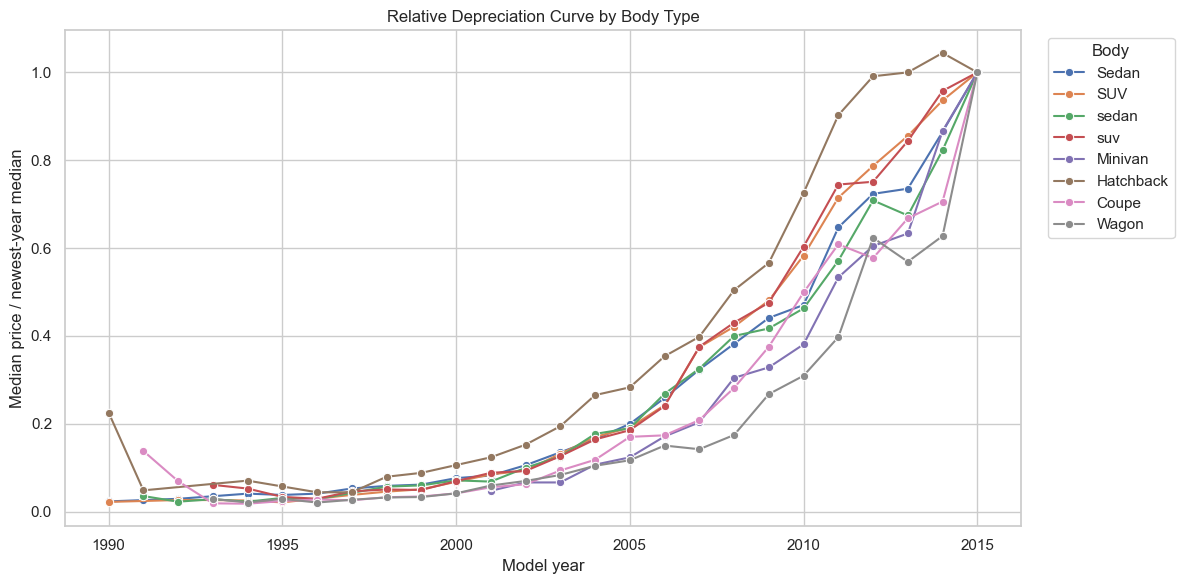

In [ ]:
# 1. Find the 8 most common car body types so our chart isn't too cluttered
body_counts = df_fe['body'].value_counts()
top_bodies = body_counts.head(8).index.tolist()

# 2. Filter our data to only include those top 8 body types
filtered_df = df_fe[df_fe['body'].isin(top_bodies)]

# 3. Calculate the median selling price for every combination of Body and Year
dep = filtered_df.groupby(['body', 'year'], as_index=False)['sellingprice'].median()

# 4. Calculate the depreciation (Price Index)
# We will do this step-by-step using a loop, which is much easier to read
processed_data = []

for body_type in top_bodies:
    # Grab the rows just for this specific body type
    body_data = dep[dep['body'] == body_type].copy()
    
    # Find the most recent (newest) model year for this body type
    newest_year = body_data['year'].max()
    
    # Get the median selling price for that newest year
    # (We use .iloc to pull the actual number out of the dataframe)
    newest_price = body_data[body_data['year'] == newest_year]['sellingprice'].iloc
    
    # Save the newest price in its own column
    body_data['newest_price'] = newest_price
    
    # Create the price index: current year price divided by newest year price
    newest_price = body_data.loc[body_data['year'] == newest_year, 'sellingprice'].iloc[0]
    body_data['newest_price'] = newest_price
    body_data['price_index'] = body_data['sellingprice'] / newest_price
    
    # Save our work to the list
    processed_data.append(body_data)

# Paste all the body types back together into one dataframe
dep = pd.concat(processed_data, ignore_index=True)


# 5. Draw the chart
# Make the chart nice and wide
plt.figure(figsize=(12, 6))

# Draw the lines, connecting the dots for each year
sns.lineplot(data=dep, x='year', y='price_index', hue='body', marker='o')

# Add our titles and labels
plt.title('Relative Depreciation Curve by Body Type')
plt.ylabel('Median price / newest-year median')
plt.xlabel('Model year')

# Move the legend outside the chart on the top right so it doesn't cover our lines
plt.legend(title='Body', bbox_to_anchor=(1.02, 1), loc='upper left')

# Tell matplotlib to adjust the spacing so nothing gets cut off
plt.tight_layout()

# (Optional: If you are running this as a script and not in Jupyter, you need this to show the plot)
# plt.show()

## EDA 2: Condition Thresholds Where Price Collapses

A linear view can hide cliffs. The next cells bin condition ratings and compute adjacent-bin percentage drops to identify threshold zones where buyers sharply discount vehicles.

   condition_bin  median_price  count  pct_change_from_prev_bin
0  (-0.001, 0.5]           NaN      0                       NaN
1     (0.5, 1.0]        2100.0   5429                       NaN
2     (1.0, 1.5]        2700.0    428                  0.285714
3     (1.5, 2.0]        3700.0  50199                  0.370370
4     (2.0, 2.5]        6600.0  36115                  0.783784
5     (2.5, 3.0]        9100.0  61392                  0.378788
6     (3.0, 3.5]       11300.0  58925                  0.241758
7     (3.5, 4.0]       13800.0  85824                  0.221239
8     (4.0, 4.5]       16200.0  87443                  0.173913
9     (4.5, 5.0]       19600.0  47968                  0.209877


C:\Users\Daksh\AppData\Local\Temp\ipykernel_25456\1777498224.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


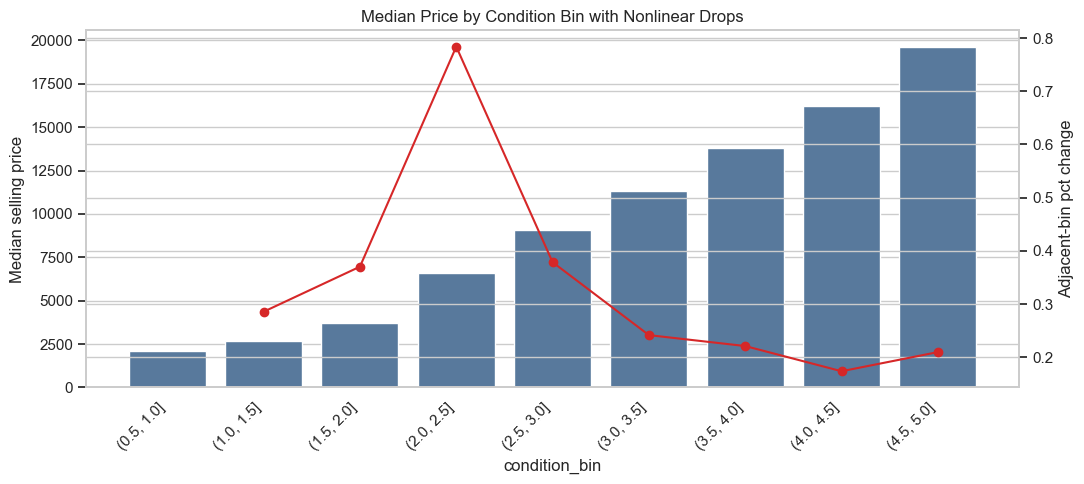

In [ ]:
# 1. Make a copy of the data, but drop any rows where we don't know the car's condition
condition_df = df_fe.dropna(subset=['condition']).copy()

# 2. Create the condition bins (0.0 to 0.5, 0.5 to 1.0, etc.)
# Instead of a lambda function, we just create a new column directly
bins_array = np.arange(0, 5.5, 0.5)
condition_df['condition_bin'] = pd.cut(condition_df['condition'], bins=bins_array, include_lowest=True)

# 3. Calculate the median price and count for each condition bin
# We group the data and apply basic aggregation functions
grouped = condition_df.groupby('condition_bin', observed=False)['sellingprice'].agg(['median', 'size'])

# 4. Clean up the resulting dataframe
# Move the condition bins from the index back into a regular column
grouped = grouped.reset_index()

# Rename the columns to be clear and match the original logic
grouped = grouped.rename(columns={'median': 'median_price', 'size': 'count'})

# 5. Calculate how much the price dropped (or rose) compared to the previous bin
grouped['pct_change_from_prev_bin'] = grouped['median_price'].pct_change()

# View the final table (using print, though display() works well if you are in Jupyter)
print(grouped)

# ---------------------------------------------------------
# Plotting the Chart
# ---------------------------------------------------------

# Create the canvas (11 units wide, 5 units tall)
fig, ax1 = plt.subplots(figsize=(11, 5))

# Draw the main bar chart for median prices
sns.barplot(data=grouped, x='condition_bin', y='median_price', ax=ax1, color='#4c78a8')

# Rotate the labels on the bottom so they don't overlap
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Add titles and labels for the first axis
ax1.set_title('Median Price by Condition Bin with Nonlinear Drops')
ax1.set_ylabel('Median selling price')

# Create a second Y-axis that shares the same X-axis
ax2 = ax1.twinx()

# Draw the line chart for percentage change on the right-side axis
# We use grouped.index for the X coordinates so the dots line up with the middle of the bars
ax2.plot(grouped.index, grouped['pct_change_from_prev_bin'], color='#d62728', marker='o')

# Add the label for the right-side axis
ax2.set_ylabel('Adjacent-bin pct change')

# Clean up the spacing so the rotated labels don't get cut off at the bottom
plt.tight_layout()

# plt.show() # Uncomment if not using a Jupyter Notebook

## EDA 3: Odometer-to-Year Ratio Versus Single Features

`miles_per_year` separates high-mileage old cars from unusually hard-driven newer cars. This tends to expose risk better than raw odometer or model year alone.

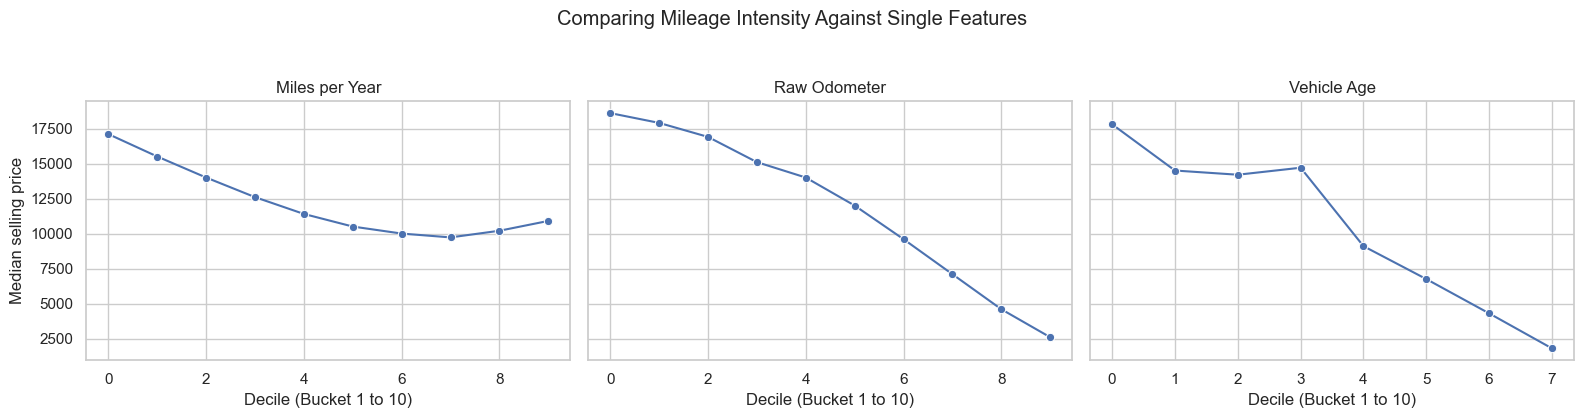

In [ ]:
# 1. Prepare the Data
mileage_view = df_fe.copy()

# Break the data into 10 equal-sized buckets (deciles) for three different metrics
mileage_view['miles_per_year_bin'] = pd.qcut(mileage_view['miles_per_year'], q=10, duplicates='drop')
mileage_view['odometer_bin'] = pd.qcut(mileage_view['odometer'], q=10, duplicates='drop')
mileage_view['age_bin'] = pd.qcut(mileage_view['car_age'], q=10, duplicates='drop')

# Calculate the median selling price for each of our new buckets
ratio_effect = mileage_view.groupby('miles_per_year_bin', observed=False)['sellingprice'].median().reset_index()
odo_effect = mileage_view.groupby('odometer_bin', observed=False)['sellingprice'].median().reset_index()
age_effect = mileage_view.groupby('age_bin', observed=False)['sellingprice'].median().reset_index()

# 2. Draw the Charts
# Create a wide canvas with 3 subplots side-by-side. 
# sharey=True means they will all use the same Y-axis scale so we can compare them easily.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# --- Chart 1: Miles per Year ---
# We use np.arange to just plot points 0, 1, 2, etc., instead of messy interval labels
x_axis_1 = np.arange(len(ratio_effect))
sns.lineplot(data=ratio_effect, x=x_axis_1, y='sellingprice', marker='o', ax=ax1)
ax1.set_title('Miles per Year')
ax1.set_xlabel('Decile (Bucket 1 to 10)')
ax1.set_ylabel('Median selling price')

# --- Chart 2: Raw Odometer ---
x_axis_2 = np.arange(len(odo_effect))
sns.lineplot(data=odo_effect, x=x_axis_2, y='sellingprice', marker='o', ax=ax2)
ax2.set_title('Raw Odometer')
ax2.set_xlabel('Decile (Bucket 1 to 10)')
# No need to set ylabel here because sharey=True handles it

# --- Chart 3: Vehicle Age ---
x_axis_3 = np.arange(len(age_effect))
sns.lineplot(data=age_effect, x=x_axis_3, y='sellingprice', marker='o', ax=ax3)
ax3.set_title('Vehicle Age')
ax3.set_xlabel('Decile (Bucket 1 to 10)')

# Add a main title over everything
plt.suptitle('Comparing Mileage Intensity Against Single Features', y=1.04)

# Adjust spacing
plt.tight_layout()

# plt.show() # Uncomment if not using a Jupyter Notebook

## EDA 4: Transmission and Body Combinations That Outperform Segment Averages

This analysis compares each body/transmission combination against its own body segment median. The residual premium is more useful for bidding than the raw combination price because it controls for segment-level price differences.

,body,transmission,combo_median,count,body_median,premium_vs_body
65,Mega Cab,automatic,34500.0,40,29750.0,4750.0
70,Minivan,NaN,16000.0,2010,11300.0,4700.0
121,coupe,manual,18800.0,436,15000.0,3800.0
49,G Sedan,manual,23675.0,32,20000.0,3675.0
119,convertible,NaN,19200.0,169,16012.5,3187.5
168,minivan,NaN,16000.0,425,13000.0,3000.0
105,Wagon,NaN,11600.0,962,8700.0,2900.0
122,coupe,NaN,17800.0,220,15000.0,2800.0
46,G Coupe,manual,25200.0,57,22400.0,2800.0
199,wagon,NaN,12200.0,253,9600.0,2600.0


C:\Users\Daksh\AppData\Local\Temp\ipykernel_3872\3671047761.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, y='label', x='premium_vs_body', palette='viridis')


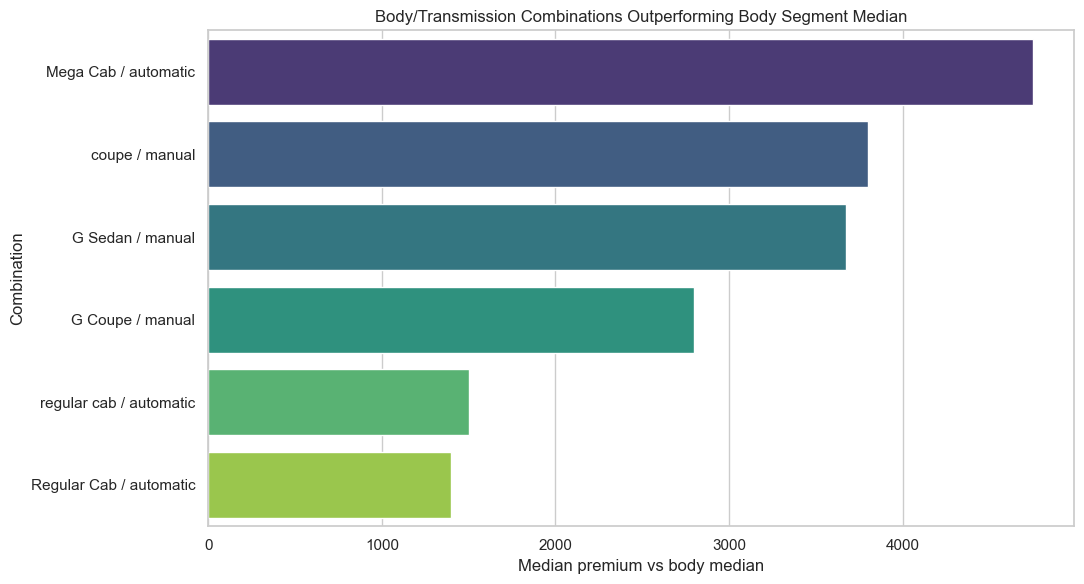

In [ ]:
# 1. Group the data by both body and transmission type
combo = df_fe.groupby(['body', 'transmission'], dropna=False)['sellingprice'].agg(['median', 'size'])
combo = combo.reset_index()

# Rename the new columns so they are easy to understand
combo = combo.rename(columns={'median': 'combo_median', 'size': 'count'})

# 2. Calculate the baseline median price for each body type (ignoring transmission entirely)
body_median = df_fe.groupby('body', dropna=False)['sellingprice'].median().reset_index()
body_median = body_median.rename(columns={'sellingprice': 'body_median'})

# 3. Merge those baseline body prices back into our combo table so they are side-by-side
combo = combo.merge(body_median, on='body', how='left')

# 4. Calculate how much more (or less) this specific combo sells for compared to the baseline
combo['premium_vs_body'] = combo['combo_median'] - combo['body_median']

# 5. Filter out rare combinations (less than 30 cars) so our data isn't skewed by outliers
combo = combo[combo['count'] >= 30]

# Sort the table so the highest premiums are at the top
combo = combo.sort_values('premium_vs_body', ascending=False)

# View the top 15 results (use print for scripts, display works in Jupyter)
print(combo.head(15))

# ---------------------------------------------------------
# Plotting the Chart
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

# Grab just the top 15 rows for the chart so it isn't cluttered
plot_data = combo.head(15).copy()

# Create a clean text label by pasting the body and transmission strings together
body_text = plot_data['body'].astype(str)
trans_text = plot_data['transmission'].astype(str)
plot_data['label'] = body_text + ' / ' + trans_text

# Draw a horizontal bar chart
sns.barplot(data=plot_data, y='label', x='premium_vs_body', palette='viridis')

# Add our titles and labels
plt.title('Body/Transmission Combinations Outperforming Body Segment Median')
plt.xlabel('Median premium vs body median')
plt.ylabel('Combination')

plt.tight_layout()

# plt.show() # Uncomment if not using a Jupyter Notebook

## Model Training and Tuning

A random forest is used because auction pricing has nonlinear interactions across make/model/body/condition/mileage and mixed feature types. Hyperparameters are tuned with `RandomizedSearchCV`; the validation set remains held out for the final tuned-versus-default comparison.

In [ ]:
X = df[RAW_FEATURES]
y = df['sellingprice']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

encoders = Auction(min_category_frequency=25, max_categories_per_column=45)
X_train_enc = encoders.fit_transform(X_train)
X_valid_enc = encoders.transform(X_valid)
X_train_enc.shape

(354444, 303)

In [ ]:
default_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
default_model.fit(X_train_enc, y_train)

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions={
        'n_estimators': [250, 400, 650],
        'max_depth': [12, 18, 26, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 0.5, 0.8],
    },
    n_iter=24,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs= -1,
    verbose=1,
)
search.fit(X_train_enc, y_train)
tuned_model = search.best_estimator_
search.best_params_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


In [ ]:
# Create a helper function to test a model and hand back its "report card"
def evaluate_model(model_name, model_object):
    
    # 1. Ask the model to guess the prices for our unseen validation data
    predictions = model_object.predict(X_valid_enc)
    
    # 2. Calculate the metrics (how good were the guesses?)
    
    # Mean Absolute Error (MAE): On average, how many dollars off was the model?
    mae = mean_absolute_error(y_valid, predictions)
    
    # Root Mean Squared Error (RMSE): Like MAE, but punishes really huge mistakes more heavily.
    # We calculate the squared error first, then take the square root to get back to dollars.
    mse = mean_squared_error(y_valid, predictions)
    rmse = np.sqrt(mse) 
    
    # R-squared (R2): What percentage of the price differences did we successfully explain? 
    # (1.0 is a perfect score, 0.0 means we just guessed the average price every time).
    r2 = r2_score(y_valid, predictions)
    
    # 3. Package the results into a simple dictionary
    results = {
        'Model Name': model_name,
        'MAE ($ off)': mae,
        'RMSE': rmse,
        'R-Squared Score': r2
    }
    
    return results

# 4. Run the evaluation for both of our models and save them to variables
default_results = evaluate_model('Default Random Forest', default_model)
tuned_results = evaluate_model('Tuned Random Forest', tuned_model)

# 5. Put those variables into a list
all_results = [default_results, tuned_results]

# 6. Convert the list into a pandas DataFrame so it prints as a nice, clean table
comparison_table = pd.DataFrame(all_results)

# 7. Print the final showdown to the console
print("--- Final Model Comparison ---")
print(comparison_table)

NameError: name 'default_model' is not defined

In [ ]:
with open('model_Daksh.pkl', 'wb') as f:
    pickle.dump(tuned_model, f)
with open('encoders_Daksh.pkl', 'wb') as f:
    pickle.dump(encoders, f)
comparison.to_csv('metrics_Daksh.csv', index=False)
print('Saved model_Daksh.pkl, encoders_Daksh.pkl, and metrics_Daksh.csv')

## Live Agent Compatibility Check

The bidding agent receives one car dictionary at a time. This check verifies that a single-row transform produces a feature vector using the saved encoder statistics. No per-evaluation means, groupbys, or category fitting are performed.

In [ ]:
# 1. Grab the very first car from our validation set.
# We convert it to a dictionary to simulate what the data would look like 
# if a user typed their car's details into a website form.
sample_car_dict = X_valid.iloc.to_dict()

# 2. Clean and encode this single car's data.
# (Because we built our Preprocessor to be smart, it can accept this dictionary directly)
single_row_features = encoders.transform(sample_car_dict)

# 3. Ask the tuned model to predict the price based on those features.
# The model always hands back a list of predictions, even if we only asked for one.
# We use to extract the actual number out of that list.
predicted_price = tuned_model.predict(single_row_features)

# 4. Print the final result clearly formatted as money.
print(f"Predicted price for the sample car: ${predicted_price:,.2f}")